In [1]:
# ============================================================
# GLOBAL FONT SETTINGS — TIMES NEW ROMAN
# ============================================================

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],

    # Axis labels
    "axes.labelsize": 12,

    # Tick labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Legend
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,

    # Figure titles
    "axes.titlesize": 13,

    # Save/export
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

print("✓ Times New Roman applied to all plots.")

✓ Times New Roman applied to all plots.


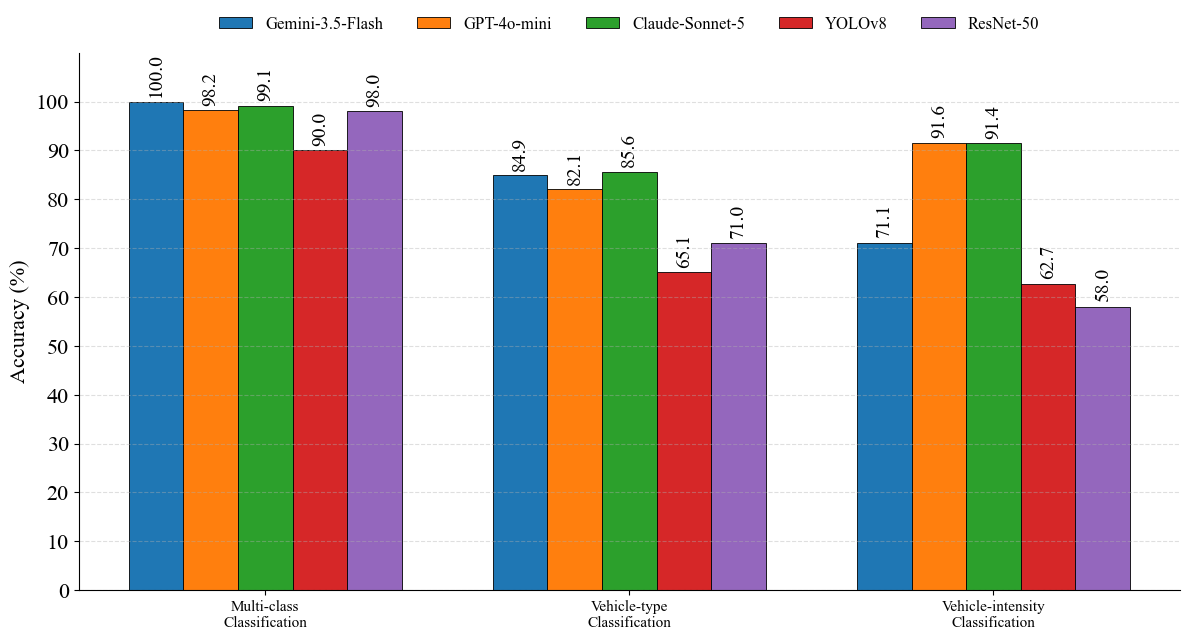

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATA
# ============================================================

models = [
    "Gemini-3.5-Flash",
    "GPT-4o-mini",
    "Claude-Sonnet-5",
    "YOLOv8",
    "ResNet-50"
]

tasks = [
    "Multi-class\nClassification",
    "Vehicle-type\nClassification",
    "Vehicle-intensity\nClassification"
]

accuracy = {
    "Gemini-3.5-Flash": [100.00, 84.91, 71.08],
    "GPT-4o-mini":      [98.18, 82.08, 91.57],
    "Claude-Sonnet-5":  [99.09, 85.58, 91.43],
    "YOLOv8":           [90.00, 65.10, 62.70],
    "ResNet-50":        [98.00, 71.00, 58.00]
}

# ============================================================
# BAR CHART
# ============================================================

x = np.arange(len(tasks))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6.5))

for i, model in enumerate(models):
    offset = (i - (len(models) - 1) / 2) * width
    
    bars = ax.bar(
        x + offset,
        accuracy[model],
        width,
        label=model,
        edgecolor="black",
        linewidth=0.6
    )

    # Add accuracy values above bars
    for bar, value in zip(bars, accuracy[model]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=14,
            rotation=90
        )

# ============================================================
# FORMATTING
# ============================================================

ax.set_ylabel("Accuracy (%)", fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=11)

ax.set_ylim(0, 110)
ax.set_yticks(np.arange(0, 101, 10))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    #title="Models",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=5,
    frameon=False,
    fontsize=12
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ============================================================
# SAVE HIGH-RESOLUTION FIGURE
# ============================================================

plt.savefig(
    "model_accuracy_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "model_accuracy_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

## Multi-class F1, Precision, Recall

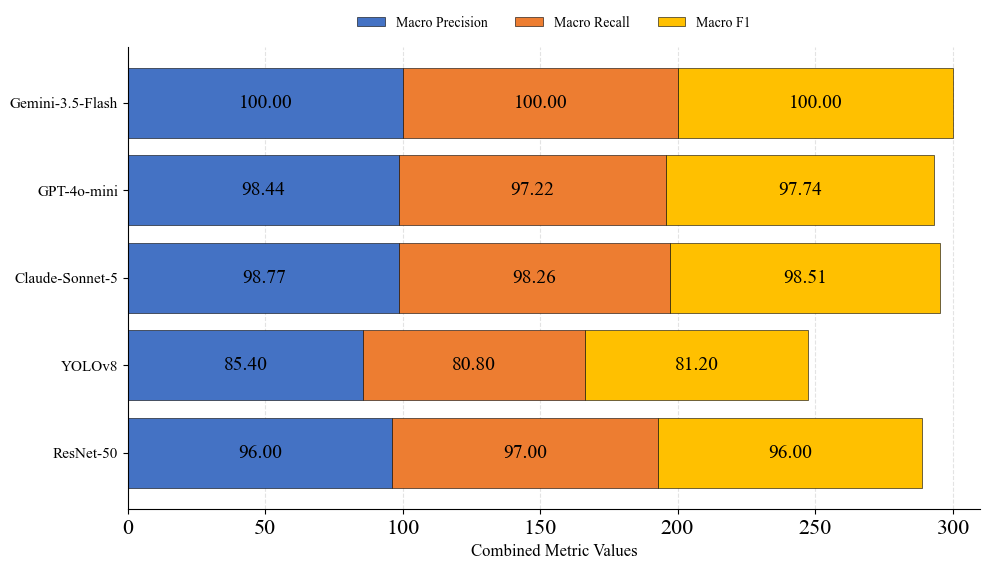

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATA
# ============================================================

models = [
    "Gemini-3.5-Flash",
    "GPT-4o-mini",
    "Claude-Sonnet-5",
    "YOLOv8",
    "ResNet-50"
]

precision = np.array([100.00, 98.44, 98.77, 85.40, 96.00])
recall    = np.array([100.00, 97.22, 98.26, 80.80, 97.00])
f1        = np.array([100.00, 97.74, 98.51, 81.20, 96.00])

y = np.arange(len(models))

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.8))

# First segment: Precision
bars1 = ax.barh(
    y,
    precision,
    label="Macro Precision",
    color="#4472C4",
    edgecolor="black",
    linewidth=0.4
)

# Second segment: Recall
bars2 = ax.barh(
    y,
    recall,
    left=precision,
    label="Macro Recall",
    color="#ED7D31",
    edgecolor="black",
    linewidth=0.4
)

# Third segment: F1
bars3 = ax.barh(
    y,
    f1,
    left=precision + recall,
    label="Macro F1",
    color="#FFC000",
    edgecolor="black",
    linewidth=0.4
)

# ============================================================
# ADD VALUES INSIDE EACH SEGMENT
# ============================================================

for i in range(len(models)):

    # Precision
    ax.text(
        precision[i] / 2,
        y[i],
        f"{precision[i]:.2f}",
        ha="center",
        va="center",
        fontsize= 14
    )

    # Recall
    ax.text(
        precision[i] + recall[i] / 2,
        y[i],
        f"{recall[i]:.2f}",
        ha="center",
        va="center",
        fontsize= 14
    )

    # F1
    ax.text(
        precision[i] + recall[i] + f1[i] / 2,
        y[i],
        f"{f1[i]:.2f}",
        ha="center",
        va="center",
        fontsize= 14
    )

# ============================================================
# FORMATTING
# ============================================================

ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=11)

# Gemini at top
ax.invert_yaxis()

ax.set_xlabel(
    "Combined Metric Values",
    fontsize=12,
    # fontweight="bold"
)

# ax.set_ylabel("Models",fontsize=12, fontweight="bold")

ax.set_xlim(0, 310)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)

# Legend
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
    fontsize=10
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "macro_metrics_stacked_horizontal.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "macro_metrics_stacked_horizontal.pdf",
    bbox_inches="tight"
)

plt.show()

## Vehicel type and Vehicle-Count 

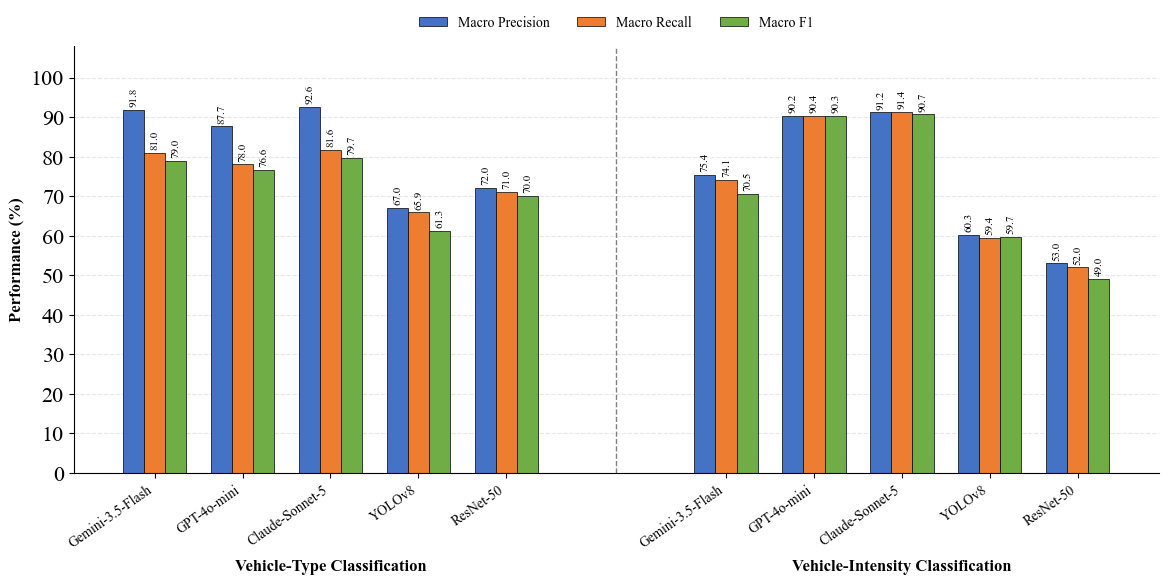

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATA
# ============================================================

models = [
    "Gemini-3.5-Flash",
    "GPT-4o-mini",
    "Claude-Sonnet-5",
    "YOLOv8",
    "ResNet-50"
]

# Vehicle-Type Classification
type_precision = [91.75, 87.67, 92.58, 67.00, 72.00]
type_recall    = [81.00, 78.04, 81.63, 65.90, 71.00]
type_f1        = [79.04, 76.62, 79.65, 61.30, 70.00]

# Vehicle-Intensity Classification
int_precision = [75.43, 90.24, 91.20, 60.30, 53]
int_recall    = [74.07, 90.37, 91.43, 59.40, 52.00]
int_f1        = [70.54, 90.29, 90.70, 59.70, 49.00]

# ============================================================
# X POSITIONS
# ============================================================

n = len(models)

# First group
x1 = np.arange(n)

# Gap between classification tasks
gap = 1.5

# Second group
x2 = np.arange(n) + n + gap

width = 0.24

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# ============================================================
# VEHICLE-TYPE CLASSIFICATION
# ============================================================

bars1 = ax.bar(
    x1 - width,
    type_precision,
    width,
    label="Macro Precision",
    color="#4472C4",
    edgecolor="black",
    linewidth=0.5
)

bars2 = ax.bar(
    x1,
    type_recall,
    width,
    label="Macro Recall",
    color="#ED7D31",
    edgecolor="black",
    linewidth=0.5
)

bars3 = ax.bar(
    x1 + width,
    type_f1,
    width,
    label="Macro F1",
    color="#70AD47",
    edgecolor="black",
    linewidth=0.5
)

# ============================================================
# VEHICLE-INTENSITY CLASSIFICATION
# ============================================================

bars4 = ax.bar(
    x2 - width,
    int_precision,
    width,
    color="#4472C4",
    edgecolor="black",
    linewidth=0.5
)

bars5 = ax.bar(
    x2,
    int_recall,
    width,
    color="#ED7D31",
    edgecolor="black",
    linewidth=0.5
)

bars6 = ax.bar(
    x2 + width,
    int_f1,
    width,
    color="#70AD47",
    edgecolor="black",
    linewidth=0.5
)

# ============================================================
# VALUE LABELS
# ============================================================

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.8,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

for bars in [bars1, bars2, bars3, bars4, bars5, bars6]:
    add_labels(bars)

# ============================================================
# X AXIS
# ============================================================

all_x = np.concatenate([x1, x2])
all_labels = models + models

ax.set_xticks(all_x)

ax.set_xticklabels(
    all_labels,
    rotation=35,
    ha="right",
    fontsize=10
)

# ============================================================
# TASK GROUP LABELS
# ============================================================

ax.text(
    np.mean(x1),
    -22,
    "Vehicle-Type Classification",
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    np.mean(x2),
    -22,
    "Vehicle-Intensity Classification",
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold"
)

# ============================================================
# DIVIDER BETWEEN TASKS
# ============================================================

divider = (x1[-1] + x2[0]) / 2

ax.axvline(
    divider,
    color="gray",
    linestyle="--",
    linewidth=1
)

# ============================================================
# FORMATTING
# ============================================================

ax.set_ylabel(
    "Performance (%)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylim(0, 108)
ax.set_yticks(np.arange(0, 101, 10))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Extra bottom space for group headings
plt.subplots_adjust(bottom=0.27)

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "vehicle_type_intensity_metrics.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "vehicle_type_intensity_metrics.pdf",
    bbox_inches="tight"
)

plt.show()